In [53]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from fcmeans import FCM
from kneed import KneeLocator

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [27]:
df = pd.read_csv('tsne_All.txt', sep="\t")
df = df.set_index('gid')
df

,GRN_V1,GRN_V2,CEN_V1,CEN_V2,GAN_V1,GAN_V2
gid,,,,,,
Zm00001d001763,0.214156,-0.494250,-1.184561,0.580770,0.825157,0.979169
Zm00001d001765,-0.923656,0.284657,0.481819,1.024282,0.606602,0.986930
Zm00001d001771,-0.160803,-1.610662,-1.132573,0.773209,0.559955,0.989992
Zm00001d001772,-0.852361,0.883947,2.131969,0.536629,0.736344,0.982411
Zm00001d001773,1.659882,-1.149979,-0.762560,-1.673977,0.825918,0.984915
...,...,...,...,...,...,...
Zm00001d054088,-0.382613,-0.247377,0.700069,0.992451,1.158951,-0.536107
Zm00001d054089,0.456596,0.267950,0.660923,1.350590,0.660222,-0.366443
Zm00001d054095,-0.558670,-1.662505,0.113749,-2.133813,1.700369,-0.963965


In [26]:
scaled_features = df.to_numpy()
scaled_features.shape

(18604, 6)

In [8]:
scaled_features

array([[ 0.21415563, -0.49424968, -1.18456093,  0.58076961,  0.82515749,
         0.97916941],
       [-0.92365566,  0.28465689,  0.4818193 ,  1.02428195,  0.60660197,
         0.98693023],
       [-0.16080303, -1.61066214, -1.13257261,  0.77320914,  0.55995456,
         0.98999225],
       ...,
       [-1.75958026,  0.68600718,  0.02995457, -0.25431609,  0.83502455,
        -1.39648111],
       [-1.62064299,  0.82041518, -1.08308581, -1.14528564, -0.24127834,
         0.23811739],
       [ 0.79296117,  1.76947814, -0.72558417, -0.90874888, -0.77190869,
        -0.16059022]])

In [7]:
# Selecting k number of clusters
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}


In [65]:

def OptimumK(scaled_vals, maxK):
    # by default test from 2 up to 30 centers
    # A list holds the SSE values for each k
    sse = []
    # A list holds the silhouette coefficients for each k
    silhouette_coefficients = []
    
    for k in range(2, maxK):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(scaled_vals)
        # elbow method
        sse.append(kmeans.inertia_)
        # silhouette    method
        score = silhouette_score(scaled_features, kmeans.labels_)
        silhouette_coefficients.append(score)    

    # optimum elbow
    kl = KneeLocator( range(2, maxK), sse, curve="convex", direction="decreasing")
    kl.elbow
        

12

In [62]:
def PlotQC_kmeans(sse_vals, elbow, silhouette_vals, ktested):
    f, axes = plt.subplots(1, 2, figsize=(15,5))
    
    axes[0].plot(range(2, ktested), sse_vals, lw=2)
    axes[0].set_xticks(range(2, ktested, 2))
    axes[0].set(xlabel="Number of Clusters", ylabel="SSE")    
    axes[0].axvline(x=kl.elbow, linestyle='--', lw=2)
    #
    axes[1].plot(range(2, ktested), silhouette_vals, lw=2)
    axes[1].set_xticks(range(2, ktested, 2))
    axes[1].set(xlabel="Number of Clusters", ylabel="Silhouette Coefficient")
    #plt.savefig('images/basic-clustering-output.jpg')
    plt.show()



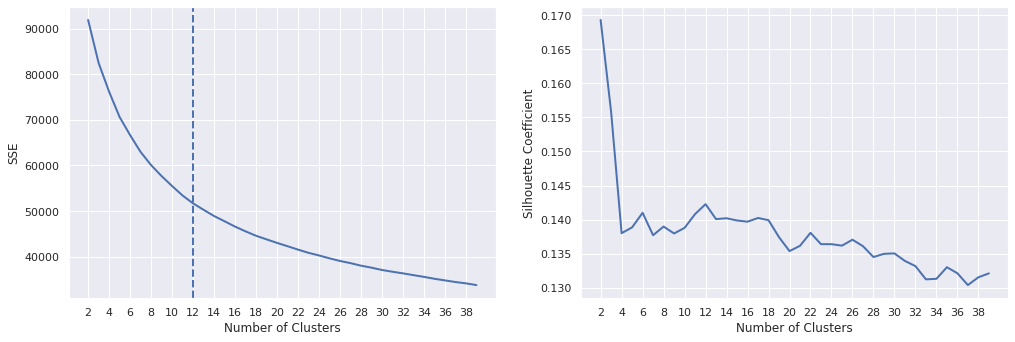

In [63]:
PlotQC_kmeans(sse,kl.elbow, silhouette_coefficients, 40)